In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [56]:
df = pd.read_csv(r"C:\Users\Vino Jayrasta S\Downloads\ecommerce.csv")

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4870 non-null   int64  
 1   StockCode    4870 non-null   str    
 2   Description  4870 non-null   str    
 3   Quantity     4870 non-null   int64  
 4   InvoiceDate  4870 non-null   str    
 5   UnitPrice    4870 non-null   float64
 6   CustomerID   4870 non-null   int64  
 7   Country      4870 non-null   str    
dtypes: float64(1), int64(3), str(4)
memory usage: 304.5 KB


In [58]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,554697,21166,COOK WITH WINE METAL SIGN,1,5/25/2011 17:31,2.08,14584,United Kingdom
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,7/24/2011 11:58,2.55,17114,United Kingdom
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,7/19/2011 12:54,1.65,15311,United Kingdom
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,7/13/2011 11:34,1.25,16843,United Kingdom
4,544450,21789,KIDS RAIN MAC PINK,3,2/20/2011 12:23,0.85,17811,United Kingdom


In [59]:
df["Country"].unique()

<StringArray>
[      'United Kingdom',              'Germany', 'United Arab Emirates',
              'Belgium',               'France',          'Netherlands',
          'Unspecified',                 'EIRE',              'Austria',
             'Portugal',               'Sweden',               'Cyprus',
                'Spain',          'Switzerland',            'Australia',
               'Greece',              'Finland',            'Singapore',
               'Norway',                'Japan',                'Italy',
      'Channel Islands',                  'RSA',               'Poland',
              'Denmark',              'Lebanon',               'Canada',
              'Iceland',               'Brazil',                'Malta',
               'Israel']
Length: 31, dtype: str

In [60]:
df["Description"].unique()

<StringArray>
[         'COOK WITH WINE METAL SIGN ',   'WOODEN PICTURE FRAME WHITE FINISH',
 'BUNDLE OF 3 ALPHABET EXERCISE BOOKS', 'CHARLIE & LOLA WASTEPAPER BIN FLORA',
                  'KIDS RAIN MAC PINK',    'SET OF 12 MINI LOAF BAKING CASES',
  'MINI CAKE STAND WITH HANGING CAKES', 'SET OF 3 WOODEN STOCKING DECORATION',
                'JUMBO BAG STRAWBERRY',       'SET OF 2 WOODEN MARKET CRATES',
 ...
            'CHILDS GARDEN BRUSH PINK',            'ROLL WRAP 50'S CHRISTMAS',
               'EMPIRE DESIGN ROSETTE',       'SMALL GLASS SUNDAE DISH CLEAR',
      'SMALL CHUNKY GLASS ROMAN  BOWL',           'HEART IVORY TRELLIS SMALL',
        'CHRISTMAS TREE PAINTED ZINC ',       '3 TIER CAKE TIN RED AND CREAM',
       'HELLO SAILOR BLUE SOAP HOLDER',  'SET 6 FOOTBALL CELEBRATION CANDLES']
Length: 1807, dtype: str

Feature Engineering
Sebelum menjawab pertanyaan analisa, dilakukan beberapa feature engineering:

- **Revenue** (Quantity × UnitPrice) — dibuat karena `Quantity` dan `UnitPrice` sendiri-sendiri belum cukup menjelaskan total pendapatan dari satu transaksi. Dua negara bisa punya `Quantity` besar tapi `UnitPrice` rendah (atau sebaliknya), sehingga mengurutkan berdasarkan salah satu kolom saja bisa menyesatkan. `Revenue` diperlukan untuk mengetahui pendapatan aktual.
- **Tahun, Bulan, Hari** — diambil dari `InvoiceDate` karena format aslinya berupa tanggal+waktu lengkap (misal `2011-05-25 17:31:00`) yang sulit langsung dikelompokkan per periode waktu tertentu. Dengan memecahnya jadi komponen terpisah, data bisa lebih mudah di-groupby berdasarkan tahun atau bulan untuk melihat tren penjualan dari waktu ke waktu (digunakan pada Pertanyaan No 3 dan No 4).
- **Periode** (format YYYY-MM) — dibuat dengan menggabungkan `Tahun` dan `Bulan` menjadi satu kolom agar data bisa langsung diurutkan dan di-groupby secara kronologis per bulan dalam satu langkah, tanpa perlu menggabungkan dua kolom terpisah setiap kali melakukan agregasi atau membuat visualisasi tren waktu.
- **jam** — diambil dari `InvoiceDate` untuk mengetahui pada jam berapa transaksi paling banyak terjadi dalam sehari, digunakan untuk menjawab Pertanyaan No 5.

# Pertanyaan 1
10 Negara dengan Revenue tertinggi ?

In [61]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [62]:
df["Revenue"].sort_values(ascending=False)

1863    3174.40
4580    2245.32
618     2046.00
4353    1627.20
2028    1326.00
         ...   
1532       0.21
611        0.19
2208       0.19
1817       0.19
3911       0.12
Name: Revenue, Length: 4870, dtype: float64

In [63]:
Revenue_Negara = df.groupby("Country")["Revenue"].sum()

In [64]:
Revenue_Negara.sort_values(ascending=False).head(10)

Country
United Kingdom    93011.36
Netherlands        3622.33
Germany            3363.77
EIRE               3156.78
France             2320.55
Sweden              988.74
Australia           937.00
Switzerland         902.52
Portugal            562.90
Finland             432.57
Name: Revenue, dtype: float64

In [65]:
top10_negara = Revenue_Negara.sort_values(ascending=False).head(10)

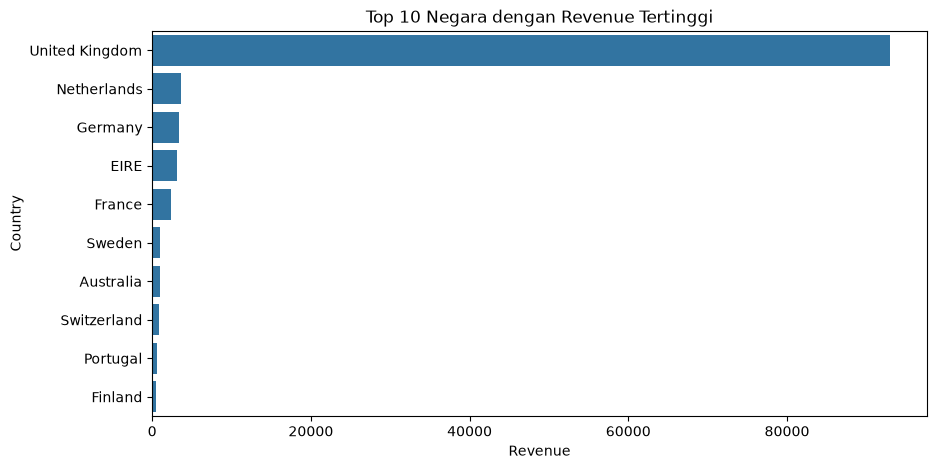

In [66]:
plt.figure(figsize=(10,5))
sns.barplot(x=top10_negara.values, y=top10_negara.index)
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.title("Top 10 Negara dengan Revenue Tertinggi")
plt.show()

Grafik menunjukkan United Kingdom mendominasi revenue secara signifikan dengan total 93.011,36, jauh melampaui negara di ranking kedua yaitu Netherlands (3.622,33) — sekitar 25,7 kali lipat lebih tinggi. Bahkan jika revenue 9 negara lainnya digabungkan (Netherlands, Germany, EIRE, France, Sweden, Australia, Switzerland, Portugal, dan Finland yang totalnya sekitar 16.287), jumlahnya masih jauh di bawah revenue UK sendiri. Ini menunjukkan bisnis sangat bergantung pada pasar UK sebagai kontributor utama revenue, sehingga mempertahankan pasar ini menjadi prioritas, sementara ekspansi ke negara-negara lain masih berpeluang dikembangkan lebih jauh mengingat kontribusinya yang masih sangat kecil.

# Pertanyaan No 2
Top 10 Produk paling banyak terjual ?

In [67]:
top10_produk = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

In [68]:
top10_produk

Description
WHITE HANGING HEART T-LIGHT HOLDER    1291
CREAM HEART CARD HOLDER               1032
WRAP, BILLBOARD FONTS DESIGN           825
JUMBO BAG RED RETROSPOT                783
MIRROR MOSAIC T-LIGHT HOLDER           720
ASSORTED COLOURS SILK FAN              648
SWEETHEART BIRD HOUSE                  621
JUMBO BAG ALPHABET                     608
JUMBO BAG STRAWBERRY                   585
PACK OF 60 PINK PAISLEY CAKE CASES     559
Name: Quantity, dtype: int64

C:\Users\Vino Jayrasta S\AppData\Local\Temp\ipykernel_28472\3791009045.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_produk.values, y=top10_produk.index, palette="viridis")


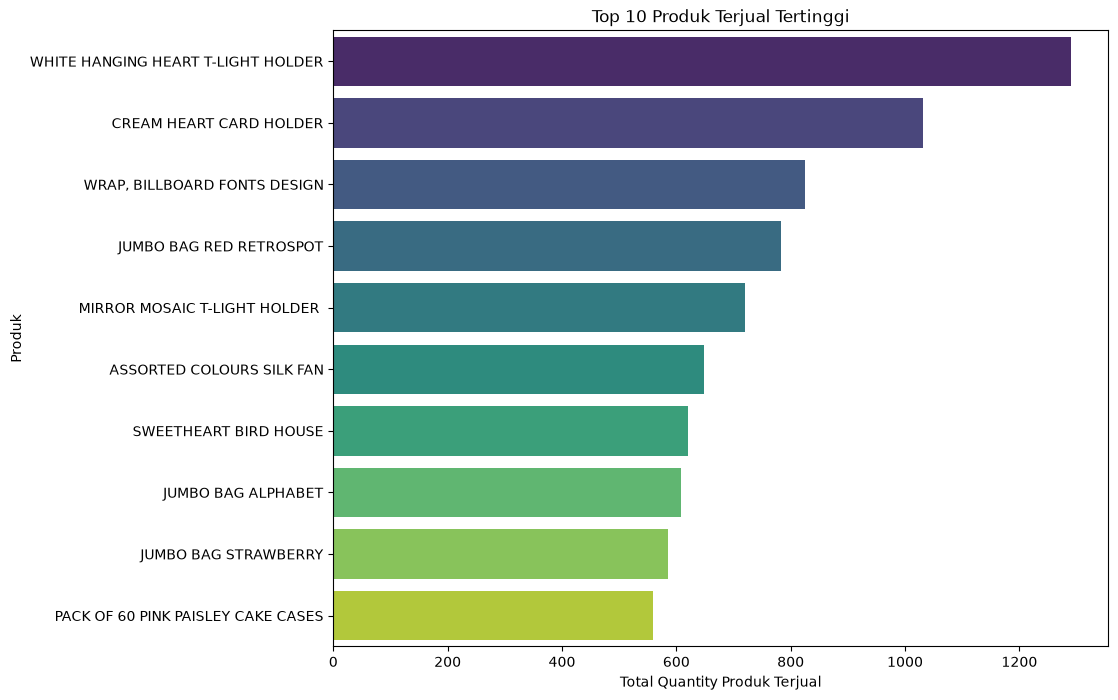

In [69]:
plt.figure(figsize=(10,8))
sns.barplot(x=top10_produk.values, y=top10_produk.index, palette="viridis")
plt.xlabel("Total Quantity Produk Terjual")
plt.ylabel("Produk")
plt.title("Top 10 Produk Terjual Tertinggi")
plt.show()

Grafik menunjukkan WHITE HANGING HEART T-LIGHT HOLDER (1.291 unit) dan CREAM HEART CARD HOLDER (1.032 unit) menjadi dua produk terlaris, jauh di atas produk lainnya yang berada di kisaran 550-820 unit. Kesenjangan ini menunjukkan penjualan tidak merata dan terkonsentrasi di sedikit produk andalan. Sebagai rekomendasi, stok untuk 2 produk teratas sebaiknya diprioritaskan agar tidak kehabisan, sementara untuk produk-produk di ranking bawah bisa didorong lewat campaign atau promosi tambahan supaya penjualannya lebih merata.

# Pertanyaan No 3
Tunjukkan trend grafik penjualan setiap tahun ?

In [70]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [71]:
df["Tahun"] = df["InvoiceDate"].dt.year
df["Bulan"] = df["InvoiceDate"].dt.month
df["Hari"] = df["InvoiceDate"].dt.day

In [72]:
df[["InvoiceDate", "Tahun", "Bulan", "Hari"]].head()

,InvoiceDate,Tahun,Bulan,Hari
0,2011-05-25 17:31:00,2011,5,25
1,2011-07-24 11:58:00,2011,7,24
2,2011-07-19 12:54:00,2011,7,19
3,2011-07-13 11:34:00,2011,7,13
4,2011-02-20 12:23:00,2011,2,20


In [73]:
df["Periode"] = df["InvoiceDate"].dt.to_period("M").astype(str)

In [74]:
penjualan_bulanan = df.groupby("Periode")["Revenue"].sum().reset_index()

In [75]:
penjualan_bulanan

,Periode,Revenue
0,2010-12,10810.55
1,2011-01,6247.52
2,2011-02,6152.46
3,2011-03,7162.64
4,2011-04,6357.63
5,2011-05,6987.24
6,2011-06,7203.93
7,2011-07,7569.27
8,2011-08,9904.91
9,2011-09,9761.11


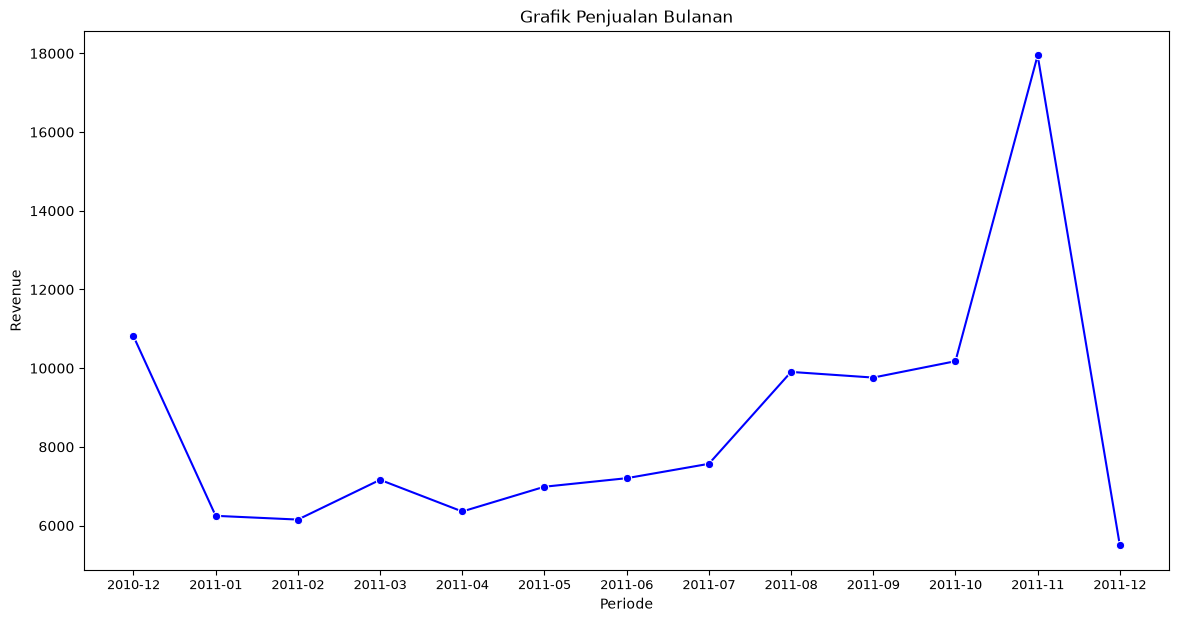

In [76]:
plt.figure(figsize=(14,7))
sns.lineplot(
    data=penjualan_bulanan,
    x="Periode",
    y="Revenue",
    marker="o",
    color="blue"
)
plt.title("Grafik Penjualan Bulanan")
plt.xticks(fontsize=9)
plt.show()

In [77]:
df[df["Periode"] == "2011-12"]["InvoiceDate"].max()

Timestamp('2011-12-09 12:31:00')

Dari grafik terlihat bahwa penjualan tertinggi terjadi di November 2011 (~18.000), dengan tren kenaikan yang mulai terlihat sejak Agustus 2011. Sementara itu, titik terendah ada di Desember 2011 (~5.500), namun ini belum bisa disimpulkan sebagai penurunan penjualan yang sesungguhnya — data untuk periode Desember 2011 hanya tersedia sampai tanggal 9 Desember, sehingga revenue-nya otomatis lebih rendah karena periode datanya belum lengkap sebulan penuh.

# Pertanyaan No 4
tunjukkan revenue 10 negara teratas setiap bulannya ?

In [78]:
top10_negara

Country
United Kingdom    93011.36
Netherlands        3622.33
Germany            3363.77
EIRE               3156.78
France             2320.55
Sweden              988.74
Australia           937.00
Switzerland         902.52
Portugal            562.90
Finland             432.57
Name: Revenue, dtype: float64

In [79]:
nama_top10 = top10_negara

In [80]:
df_top10 = df[df["Country"].isin(nama_top10.index)]

In [81]:
data = df_top10.pivot_table(index = df["Periode"], columns = ["Country"], values = ["Revenue"], aggfunc = "sum")

In [82]:
data

Revenue                                                       \
Country Australia    EIRE Finland  France Germany Netherlands Portugal   
Periode                                                                  
2010-12       NaN  159.00     NaN   98.30  200.46         NaN    25.50   
2011-01     27.00   87.60  244.08  202.21  209.50      208.32    85.80   
2011-02       NaN  251.17     NaN  102.42  213.15      360.00      NaN   
2011-03    564.00   94.29  122.04  160.26  431.82      105.00      NaN   
2011-04       NaN   60.60     NaN   30.60  356.75       90.00    35.40   
2011-05     66.48  136.50     NaN   68.10  171.45      365.60     4.95   
2011-06    126.72   92.90     NaN  549.90  290.92      855.75      NaN   
2011-07     44.40  968.30   24.90  343.60  171.22         NaN    16.50   
2011-08     91.80  115.72     NaN   60.90  237.89      697.00      NaN   
2011-09     16.60  110.86     NaN  265.65  224.98      580.00    12.50   
2011-10       NaN  281.90   41.55  131.74  481.75      278.16    73.25   
2011-11       NaN  701.44     NaN  220.35  320.02       82.50      NaN   
2011-12       NaN   96.50     NaN   86.52   53.86         NaN   309.00   

                                            
Country  Sweden Switzerland United Kingdom  
Periode                                     
2010-12  208.80         NaN        9924.99  
2011-01   75.60       20.10        4772.16  
2011-02     NaN      108.62        4712.69  
2011-03  264.00      156.60        5134.13  
2011-04   15.30       39.60        5589.68  
2011-05     NaN       20.80        6080.95  
2011-06   20.40         NaN        4993.20  
2011-07   17.34       82.00        5721.22  
2011-08   40.00      177.38        8277.62  
2011-09   17.00         NaN        8364.72  
2011-10  300.00      137.94        8224.62  
2011-11   30.30      159.48       16319.30  
2011-12     NaN         NaN        4896.08

In [83]:
df[["Quantity", "UnitPrice", "Revenue"]].corr()

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.083283,0.788586
UnitPrice,-0.083283,1.000000,0.091612
Revenue,0.788586,0.091612,1.000000


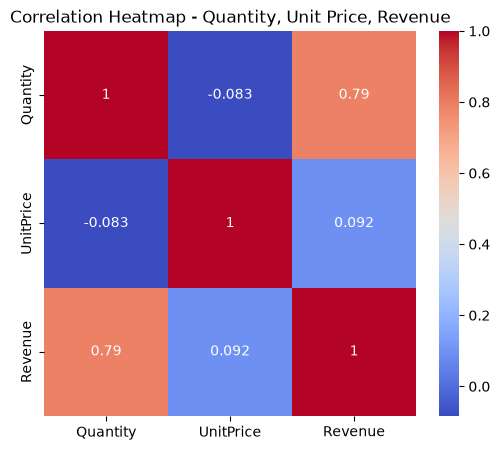

In [84]:
plt.figure(figsize=(6,5))
sns.heatmap(df[["Quantity", "UnitPrice", "Revenue"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Quantity, Unit Price, Revenue")
plt.show()

Korelasi antara Quantity dan Revenue sangat kuat (0.79), sedangkan UnitPrice terhadap Revenue cenderung lemah (0.09) dan UnitPrice terhadap Quantity hampir tidak ada korelasi (-0.08). Ini menunjukkan bahwa revenue lebih banyak didorong oleh jumlah barang yang terjual (quantity) dibandingkan harga satuannya artinya strategi menaikkan harga saja tanpa menjaga volume penjualan kemungkinan tidak akan berdampak besar terhadap revenue.

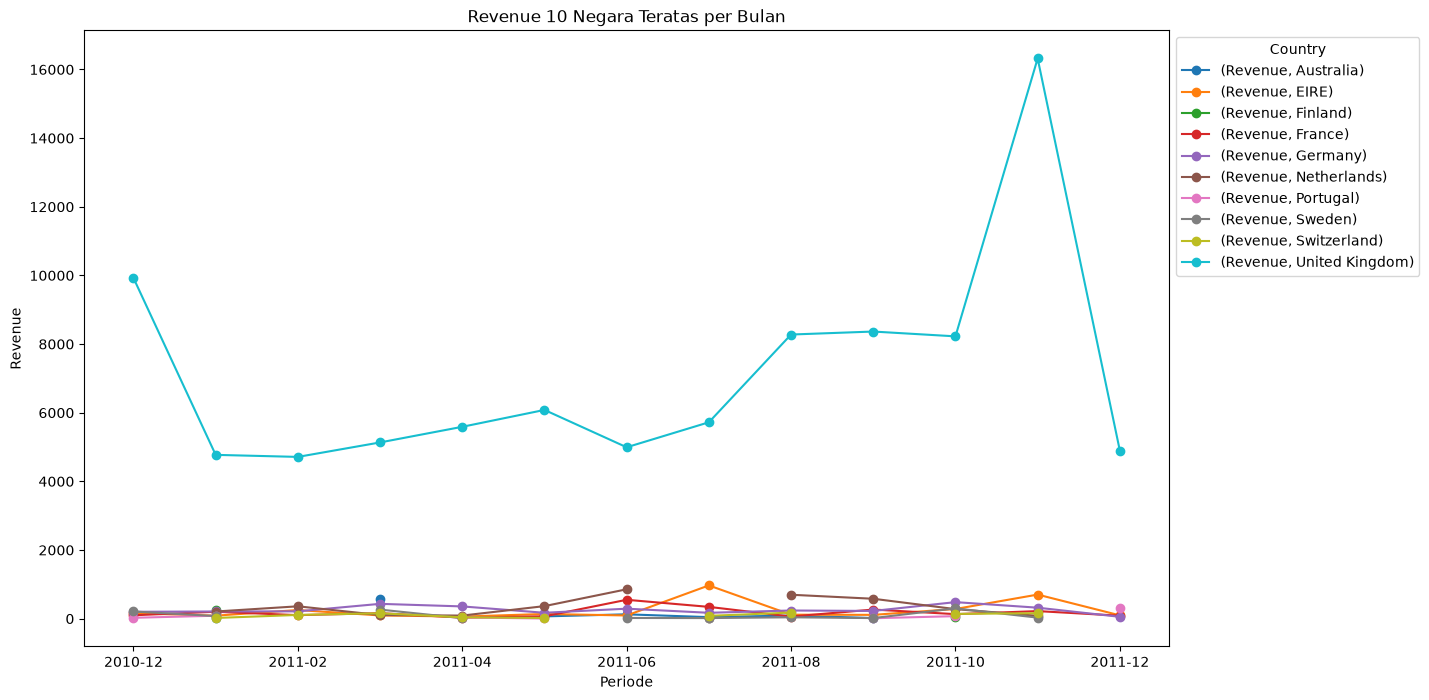

In [85]:
data.plot(figsize=(14, 8), marker="o")
plt.title("Revenue 10 Negara Teratas per Bulan")
plt.xlabel("Periode", fontsize=10)
plt.ylabel("Revenue")
plt.legend(title="Country", bbox_to_anchor=(1.0, 1), loc="upper left")
plt.xticks()
plt.show()

Grafik menunjukkan bahwa revenue United Kingdom jauh mendominasi dibanding 9 negara lainnya di sepanjang periode — bahkan di titik terendahnya (~4.700 di awal 2011), UK tetap jauh di atas gabungan negara lain yang seluruhnya berada di kisaran 0–1.000. Terlihat juga tren revenue UK cenderung naik dari pertengahan 2011, dengan puncak tertinggi di November 2011 (>16.000), sebelum turun kembali di Desember. Sementara itu, 9 negara lainnya (EIRE, Netherlands, Germany, France, dst) polanya relatif landai dan berdekatan satu sama lain, tanpa ada yang menonjol secara signifikan.

# Pertanyaan No 5
di jam berapa transaksi ramai ?

In [86]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Tahun,Bulan,Hari,Periode
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,2.08,2011,5,25,2011-05
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,5.10,2011,7,24,2011-07
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,1.65,2011,7,19,2011-07
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,15.00,2011,7,13,2011-07
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,2.55,2011,2,20,2011-02


In [87]:
df["jam"] = df["InvoiceDate"].dt.hour

In [88]:
transaksi_jam = df.groupby('jam')['CustomerID'].count()

In [89]:
transaksi_jam.sort_values(ascending=False)

jam
12    902
13    773
14    686
11    586
15    562
10    464
9     263
16    263
17    172
8     102
18     41
19     40
20     11
7       5
Name: CustomerID, dtype: int64

In [90]:
pd.crosstab(index=df["jam"], columns="Jumlah Transaksi")

col_0,Jumlah Transaksi
jam,
7,5
8,102
9,263
10,464
11,586
12,902
13,773
14,686
15,562


C:\Users\Vino Jayrasta S\AppData\Local\Temp\ipykernel_28472\3111770085.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=transaksi_jam.index, y=transaksi_jam.values, palette="viridis")


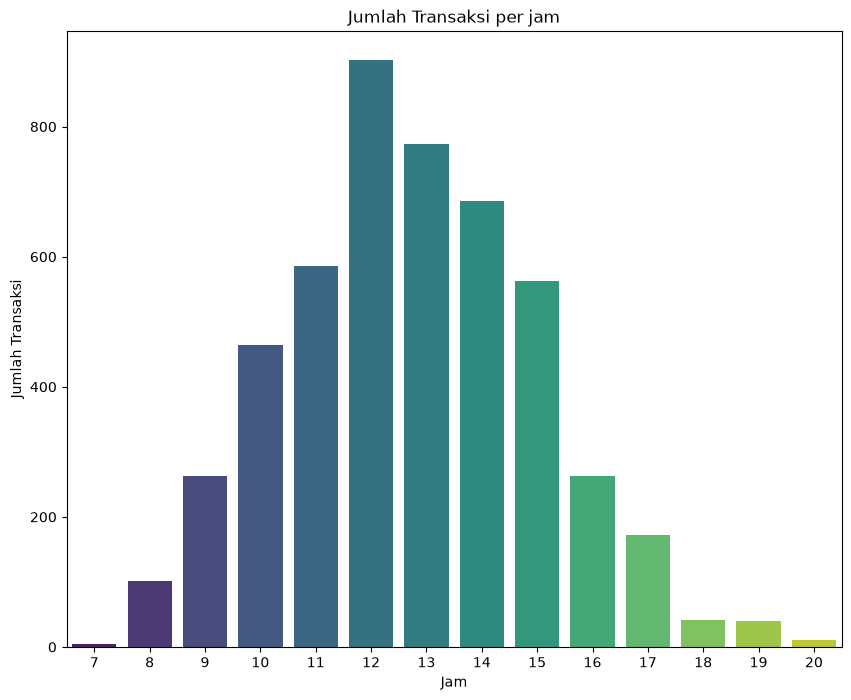

In [91]:
plt.figure(figsize=(10,8))
sns.barplot(x=transaksi_jam.index, y=transaksi_jam.values, palette="viridis")
plt.xlabel("Jam")
plt.ylabel("Jumlah Transaksi")
plt.title("Jumlah Transaksi per jam")
plt.show()

Dari grafik terlihat bahwa transaksi mulai muncul sejak jam 07.00, meningkat tajam menuju puncaknya di jam 12.00, lalu berangsur menurun hingga sore dan hampir tidak ada transaksi di jam 20.00. Pola ini menunjukkan bahwa aktivitas belanja pelanggan terkonsentrasi di jam siang (sekitar jam 11.00–15.00), kemungkinan bertepatan dengan waktu istirahat/makan siang, sementara di luar jam kerja/jam malam transaksi jauh lebih sedikit.